# Trabajo Final: Análisis de la Inversión Pública en el Perú

**Grupo 5:** 

* Rodas Cienfuegos, Ulises Alexander. F0558795
* Gamarra Mendoza Milagros Georgina. 20185844
* Linares Herrera, Durga Valentina. F1482478
* María Lesly León Huamán. 20166498


## 1. Selección y Planteamiento del Problema

**Elección del Dataset:**
Para el presente proyecto se ha seleccionado el dataset "Public Investments in Peru", el cual consolida información del Sistema Nacional de Programación Multianual y Gestión de Inversiones del 2020-2024. La relevancia de este conjunto de datos radica en que permite auditar y comprender la distribución territorial y sectorial de los recursos del Estado. Analizar esta información es clave para identificar disparidades regionales, prioridades reales de política pública y posibles ineficiencias (sobrecostos) en la ejecución de proyectos de inversión.

**Link:** [Dataset: Public Investments in Peru](https://www.kaggle.com/datasets/jenifergrategarro/dataset-public-investments-in-peru/data)

**Pregunta de Investigación / Problemática:**
* **¿Cuáles son las principales distorsiones en la ejecución de la inversión pública peruana y cómo afectan estas fallas de planificación a la rentabilidad social y la equidad territorial en el periodo analizado?**

## 2. Importación de módulos

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [2]:
# 1. Subimos un nivel (saldrá de 'analysis' y verá a las otras 3 carpetas hermanas)
sys.path.append(os.path.abspath(".."))

from queries.script_queries import (
    obtener_inversion_por_region,
    analizar_desviacion_sectorial,
    obtener_ranking_regional_top3,
    clasificar_magnitud_proyectos,
    analizar_rentabilidad_social,
    analizar_efecto_callao_atomizacion, 
    analizar_brecha_centralizacion,
    obtener_top_10_proyectos_mas_caros # <--- ¡La nueva función!
)

# 3. Configuramos la conexión a PostgreSQL
load_dotenv() 

DB_USER = "postgres" 
DB_PASSWORD = os.getenv('alnilam') # CAMBIAR CON LA VARIABLE DE ENTORNO LOCAL
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "inversion_publica_db"

cadena_conexion = f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?client_encoding=utf8'
engine = create_engine(cadena_conexion)

print("✅ ¡Conexión y módulos cargados con éxito!")

✅ ¡Conexión y módulos cargados con éxito!


## 3. Análisis de Resultados

### 3.1. Concentración Regional de la Inversión
El primer paso es entender cómo el Estado distribuye el presupuesto a lo largo del territorio nacional. A continuación, extraemos el Top 10 de los departamentos con mayor presupuesto asignado a proyectos activos.

C:\Users\alnil\AppData\Local\Temp\ipykernel_28404\3185465427.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


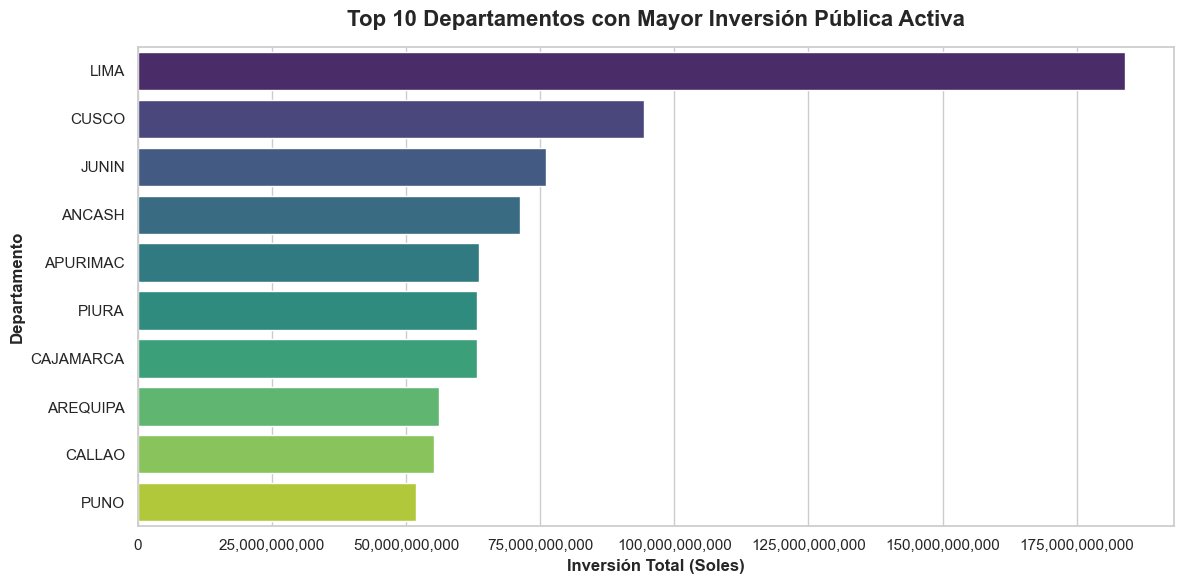

In [3]:
# Extraemos los datos usando nuestro módulo
df_inversion_regional = obtener_inversion_por_region(engine)
top_10_regiones = df_inversion_regional.head(10)

# Configuramos la visualización
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    data=top_10_regiones, 
    x='inversion_total', 
    y='departamento', 
    palette='viridis' 
)

plt.title('Top 10 Departamentos con Mayor Inversión Pública Activa', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Inversión Total (Soles)', fontsize=12, fontweight='bold')
plt.ylabel('Departamento', fontsize=12, fontweight='bold')

# Formato numérico para el eje X (quitar notación científica)
barplot.ticklabel_format(style='plain', axis='x')
barplot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

Sin embargo, muchas veces un solo proyecto puede significar la mayoría del presupuesto en estos años:

In [5]:
# 1. Extraemos los datos
df_top10 = obtener_top_10_proyectos_mas_caros(engine)

# 2. Le damos un formato visual elegante usando la función "style" de Pandas
tabla_formateada = df_top10.style.format({
    "Costo Total (S/)": "S/ {:,.2f}" # Le pone el símbolo de soles y separadores de miles
}).hide(axis="index").set_properties(**{
    'text-align': 'left',
    'font-size': '12px',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
])

# 3. Mostramos la tabla
tabla_formateada

Nombre del Proyecto,Sector,Departamento,Costo Total (S/)
"CREACION DEL SERVICIO FERROVIARIO INTERURBANO EN SAN JUAN DE MARCONA – ANDAHUAYLAS, DISTRITO DE MARCONA, PROVINCIA DE NASCA DEL DEPARTAMENTO DE ICA - DISTRITO DE JOSE MARIA ARGUEDAS DE LA PROVINCIA DE ANDAHUAYLAS DEL DEPARTAMENTO DE APURIMAC",TRANSPORTES Y COMUNICACIONES,APURIMAC,"S/ 30,552,699,580.07"
"CREACION DEL SERVICIO DE TRANSITABILIDAD VIAL INTERURBANA EN LA NUEVA CARRETERA CENTRAL ATE – CIENEGUILLA – ANTIOQUÍA - SANTO DOMINGO DE OLLEROS - CUENCA -LANGA – HUAROCHIRI - SAN MATEO - YAULI - EMP. PE-22 , DISTRITO DE YAULI DE LA PROVINCIA DE YAULI DEL DEPARTAMENTO DE JUNIN",TRANSPORTES Y COMUNICACIONES,JUNIN,"S/ 24,528,949,829.00"
"CREACION DEL SERVICIO FERROVIARIO INTERURBANO EN EL FERROCARRIL LIMA – ICA, DISTRITO DE LA TINGUILLA, PROVINCIA DE ICA DEL DEPARTAMENTO DE ICA - DISTRITO DE VILLA EL SALVADOR DE LA PROVINCIA DE LIMA DEL DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,LIMA,"S/ 24,514,698,856.70"
"CREACION DE LA LINEA 3 DE LA RED BASICA DEL METRO DE LIMA, PROVINCIA DE LIMA, DEPARTAMENTO DE LIMA DISTRITO DE LIMA - PROVINCIA DE LIMA - DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,LIMA,"S/ 23,569,314,021.37"
"CONSTRUCCION DE LA LINEA 2 Y RAMAL AV. FAUCETT-GAMBETTA DE LA RED BASICA DEL METRO DE LIMA Y CALLAO PROVINCIAS DE LIMA Y CALLAO, DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,CALLAO,"S/ 17,212,930,870.64"
"CREACION DE LA LINEA 4 DEL METRO DE LIMA Y CALLAO, PROVINCIAS DE LIMA Y CALLAO, DEPARTAMENTO DE LIMA SAN ISIDRO DEL DISTRITO DE SAN ISIDRO - PROVINCIA DE LIMA - DEPARTAMENTO DE LIMA",TRANSPORTES Y COMUNICACIONES,CALLAO,"S/ 12,615,095,387.88"
CONSTRUCCION DEL ANILLO VIAL PERIFÉRICO DE LA CIUDAD DE LIMA Y CALLAO,ECONOMIA Y FINANZAS,CALLAO,"S/ 6,771,889,600.00"
"MEJORAMIENTO Y AMPLIACION DE LOS SERVICIOS DE AGUA POTABLE Y ALCANTARILLADO EN LOS SECTORES DEL 400 AL 425 - DISTRITO DE SAN JUAN DE LURIGANCHO - PROVINCIA DE LIMA - DEPARTAMENTO DE LIMA Y LOS ANEXOS 2, 21, 24 Y MINAS DE PEDREGAL - DISTRITO DE SAN ANTONIO - PROVINCIA DE HUAROCHIRI - DEPARTAMENTO DE LIMA",FONAFE,LIMA,"S/ 6,136,452,982.23"
PROYECTO CHAVIMOCHIC TERCERA ETAPA,GOBIERNOS REGIONALES,LA LIBERTAD,"S/ 3,887,949,069.92"
CREACION DEL SERVICIO DE TRANSITABILIDAD VIAL INTERURBANA EN VIA DE EVITAMIENTO DE CUSCO DISTRITO DE SANTIAGO DE LA PROVINCIA DE CUSCO DEL DEPARTAMENTO DE CUSCO,TRANSPORTES Y COMUNICACIONES,CUSCO,"S/ 3,577,766,469.44"


### 3.2. Desviación Presupuestal por Sector (Sobrecostos)
Más allá de la cantidad invertida, es fundamental evaluar la eficiencia del gasto. Analizaremos qué sectores presentan la mayor variación porcentual entre el costo inicial estimado y el costo total actualizado de sus proyectos.

In [4]:
# Extraemos y mostramos los 10 sectores con mayores sobrecostos promedio
df_desviacion = analizar_desviacion_sectorial(engine)
df_desviacion.head(10)

,nombre_sector,num_proyectos,desviacion_promedio_pct
0,EDUCACION,2919,462.61
1,ECONOMIA Y FINANZAS,79,174.39
2,PRESIDENCIA DEL CONSEJO DE MINISTROS,161,129.62
3,RELACIONES EXTERIORES,14,123.87
4,CONTRALORIA GENERAL,6,80.87
5,UNIVERSIDADES,38,78.74
6,PRODUCCION,247,73.58
7,TRANSPORTES Y COMUNICACIONES,1480,47.49
8,AMBIENTAL,122,41.79
9,COMERCIO EXTERIOR Y TURISMO,83,39.64


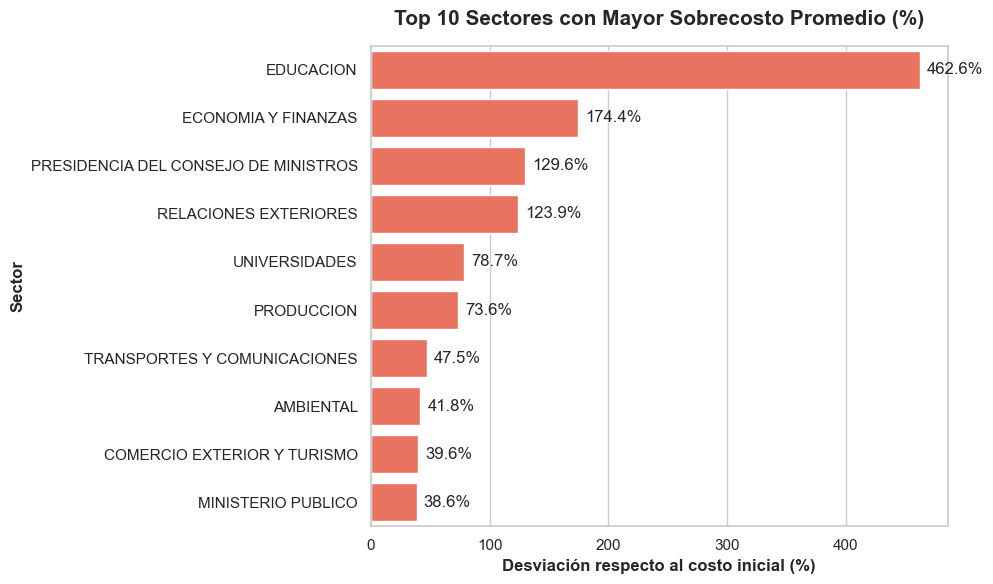

In [5]:
# 1. Extraemos los datos de sobrecostos
df_sobrecostos = analizar_desviacion_sectorial(engine)

# 2. Filtramos sectores que tengan al menos 10 proyectos para evitar sesgos estadísticos
df_filtrado = df_sobrecostos[df_sobrecostos['num_proyectos'] > 10].head(10)

# 3. Configuramos el gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Usamos color rojo/naranja para dar la idea de "alerta" en sobrecostos
barplot_costos = sns.barplot(
    data=df_filtrado, 
    x='desviacion_promedio_pct', 
    y='nombre_sector', 
    color='tomato'
)

plt.title('Top 10 Sectores con Mayor Sobrecosto Promedio (%)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Desviación respecto al costo inicial (%)', fontsize=12, fontweight='bold')
plt.ylabel('Sector', fontsize=12, fontweight='bold')

# Agregamos el porcentaje exacto al final de cada barra para mayor claridad
for i in barplot_costos.containers:
    barplot_costos.bar_label(i, fmt='%.1f%%', padding=5)

plt.tight_layout()
plt.show()

Ese 462.6% de desviación en el sector Educación no es un simple error de cálculo contable; es el reflejo de un sistema colapsado. Que un proyecto termine costando casi cinco veces y media su valor original nos habla de tres fenómenos graves:

* **Expedientes técnicos deficientes:** Se aprueban obras en papel sin estudios de suelo reales o sin prever la logística en zonas rurales, lo que obliga a inyectar más y más dinero (adendas) durante la ejecución.

* **Obras paralizadas y destrabadas:** Muchos colegios quedan a medio construir por disputas legales con contratistas. Años después, cuando el Estado intenta retomar la obra, los materiales están arruinados y los costos se han disparado por la inflación.

* **El costo social:** Mientras el presupuesto es absorbido por estas ineficiencias, miles de estudiantes siguen estudiando en módulos prefabricados. El sobrecosto en Educación es, literalmente, dinero que ya no se puede usar para construir el siguiente colegio o mejorar salarios docentes.

Más información en: [Link](https://gestion.pe/economia/ahora-casi-14-mil-obras-publicas-en-peru-son-mas-caras-que-lo-previsto-al-inicio-noticia/)

### 3.3. Focalización de la Inversión: Megaproyectos vs. Obras Menores
La magnitud financiera de los proyectos nos permite entender la estrategia de desarrollo territorial del Estado. A continuación, clasificamos los proyectos activos en tres categorías: intervenciones menores (menos de 1 millón de soles), proyectos medianos (1 a 10 millones) y megaproyectos (más de 10 millones), evaluando qué sectores concentran las grandes obras de infraestructura frente a intervenciones a microescala.

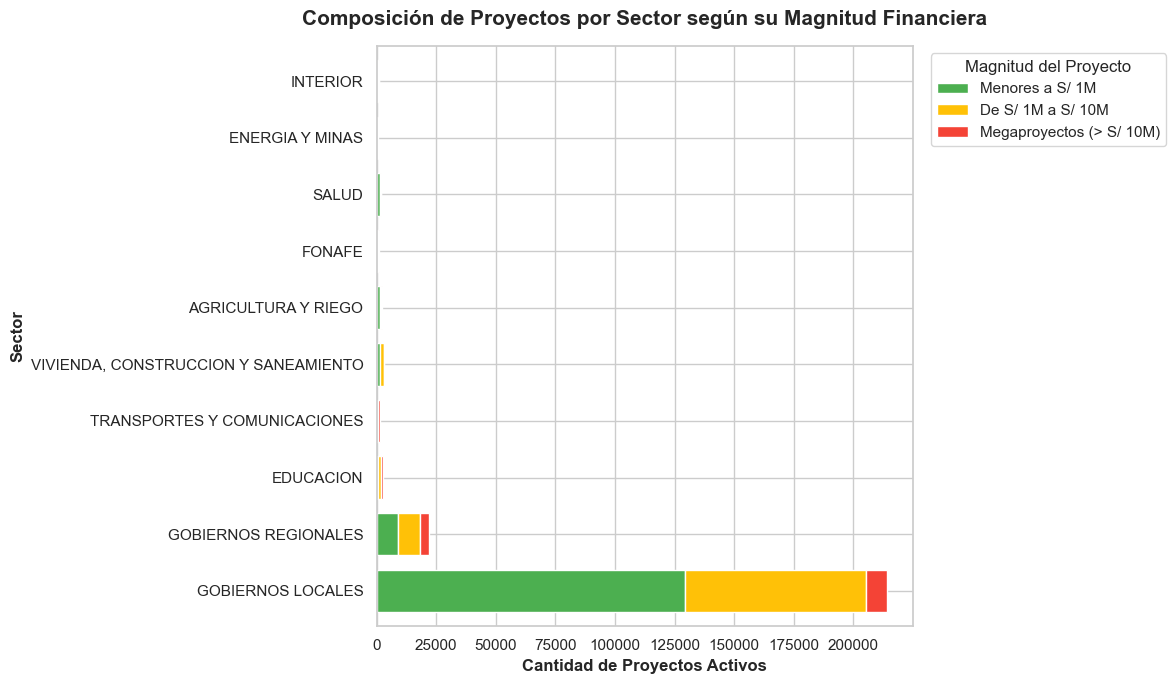

In [6]:
# 1. Extraemos los datos usando tu función
df_magnitud = clasificar_magnitud_proyectos(engine)

# 2. Tomamos el Top 10 de sectores (la consulta ya los ordena por cantidad de megaproyectos)
top_10_magnitud = df_magnitud.head(10).copy()

# 3. Preparamos el DataFrame para que el gráfico apilado funcione perfectamente
top_10_magnitud.set_index('nombre_sector', inplace=True)

# 4. Configuramos los colores y creamos el gráfico directamente con Pandas y Matplotlib
colores = ['#4CAF50', '#FFC107', '#F44336'] # Verde (Pequeños), Amarillo (Medianos), Rojo (Megaproyectos)
etiquetas_leyenda = ['Menores a S/ 1M', 'De S/ 1M a S/ 10M', 'Megaproyectos (> S/ 10M)']

# Plot apilado
ax = top_10_magnitud.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7), 
    color=colores,
    width=0.75
)

# 5. Títulos y etiquetas del gráfico
plt.title('Composición de Proyectos por Sector según su Magnitud Financiera', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Proyectos Activos', fontsize=12, fontweight='bold')
plt.ylabel('Sector', fontsize=12, fontweight='bold')

# 6. Ajustamos la leyenda para que no tape las barras
plt.legend(etiquetas_leyenda, title='Magnitud del Proyecto', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Este gráfico revela lo que en gestión pública llamamos la **"hiper-atomización del gasto"**.

* **Barra verde / Barra amarilla en Gobiernos locales**: Tienen decenas de miles de proyectos, pero la inmensa mayoría son obras menores a 1 millón o menores a 10 millones.

* **Lógica política vs. Lógica de desarrollo:** Muchos alcaldes prefieren hacer 50 parquecitos, losas deportivas, veredas o refacciones pequeñas (la barra verde) porque se construyen rápido y generan visibilidad política inmediata (clientelismo o rentabilidad electoral). Sin embargo, estas micro-obras rara vez cambian la aguja del desarrollo estructural.

* **Falta de capacidad técnica:** La descentralización le dio dinero a los municipios, pero no les dio ingenieros ni proyectistas de alto nivel. Por eso casi no hacen megaproyectos (la barra roja es mínima en proporción). El Estado está gastando miles de millones "a goteo", en lugar de consolidar grandes corredores económicos, hospitales regionales o redes de agua integrales.

Más información: [Informe de Comex Perú](https://www.comexperu.org.pe/articulo/gestion-municipal-en-2025-el-967-requiere-asistencia-tecnica-o-capacitacion); [Informe de La República](https://especial.larepublica.pe/metro-cuadrado/vivienda-y-construccion/2026/02/03/municipios-con-millones-sin-gastar-por-que-tantas-obras-publicas-siguen-paralizadas-en-el-peru-265410)

### 3.4. El "Efecto Callao" vs. La Atomización del Gasto
Al cruzar la cantidad de proyectos con el costo promedio por obra, emergen dos modelos opuestos de gestión pública: la alta atomización (miles de obras de bajo presupuesto, como en Áncash) frente a la concentración en megaproyectos (pocas obras de altísimo presupuesto, como el "Efecto Callao").

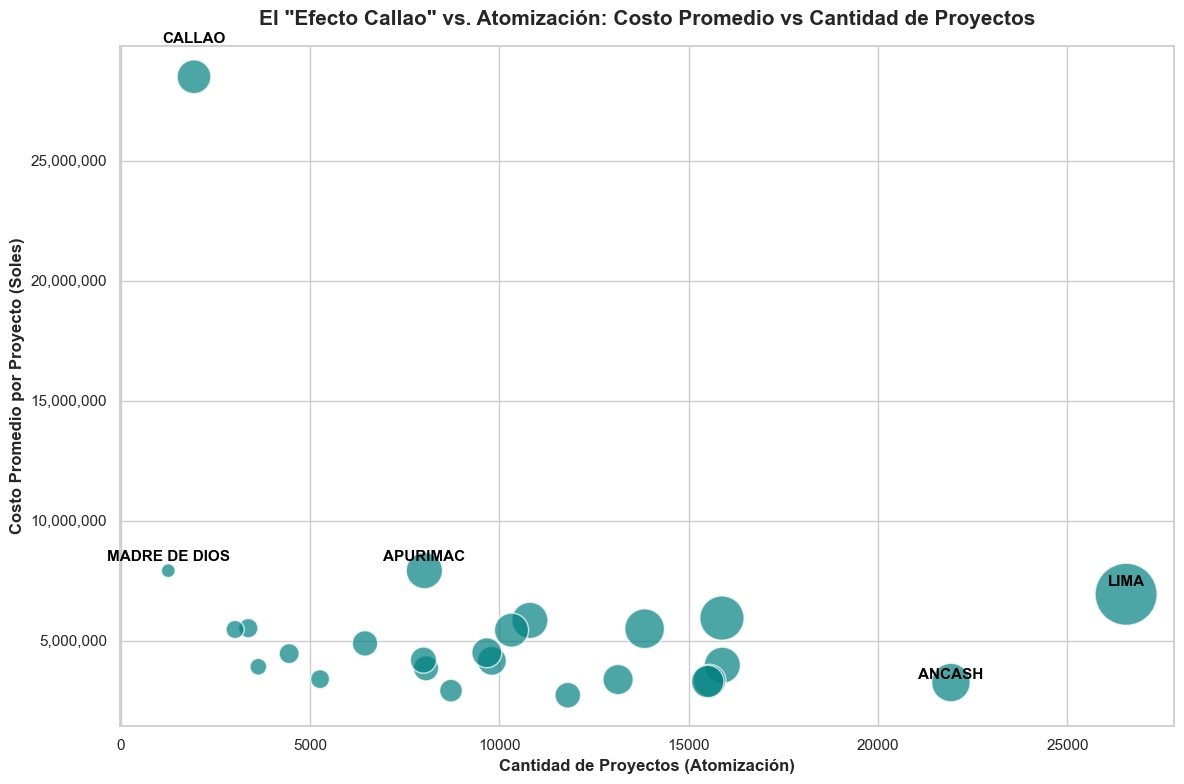

In [7]:
df_dispersion = analizar_efecto_callao_atomizacion(engine)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=df_dispersion, x='cantidad_proyectos', y='costo_promedio',
    size='inversion_total', sizes=(100, 2000), alpha=0.7, color='teal', legend=False
)

regiones_clave = ['CALLAO', 'ANCASH', 'LIMA', 'MADRE DE DIOS', 'APURIMAC']
for i in range(df_dispersion.shape[0]):
    reg = df_dispersion['departamento'].iloc[i]
    x_val = df_dispersion['cantidad_proyectos'].iloc[i]
    y_val = df_dispersion['costo_promedio'].iloc[i]
    if reg in regiones_clave:
        plt.text(x_val, y_val + (y_val*0.05), reg, horizontalalignment='center', size='11', color='black', weight='bold')

plt.title('El "Efecto Callao" vs. Atomización: Costo Promedio vs Cantidad de Proyectos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Proyectos (Atomización)', fontsize=12, fontweight='bold')
plt.ylabel('Costo Promedio por Proyecto (Soles)', fontsize=12, fontweight='bold')

scatter.ticklabel_format(style='plain', axis='y')
scatter.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()

### 3.7. Rentabilidad Social: Costo por Beneficiario
Más allá de la magnitud financiera, evaluamos la inversión pública por su impacto humano. Este indicador revela cuánto dinero invierte el Estado para impactar a un solo ciudadano (per cápita), permitiéndonos identificar sectores con un costo de intervención extremadamente alto frente a otros de impacto masivo.

C:\Users\alnil\AppData\Local\Temp\ipykernel_28404\3963832223.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot_impacto = sns.barplot(


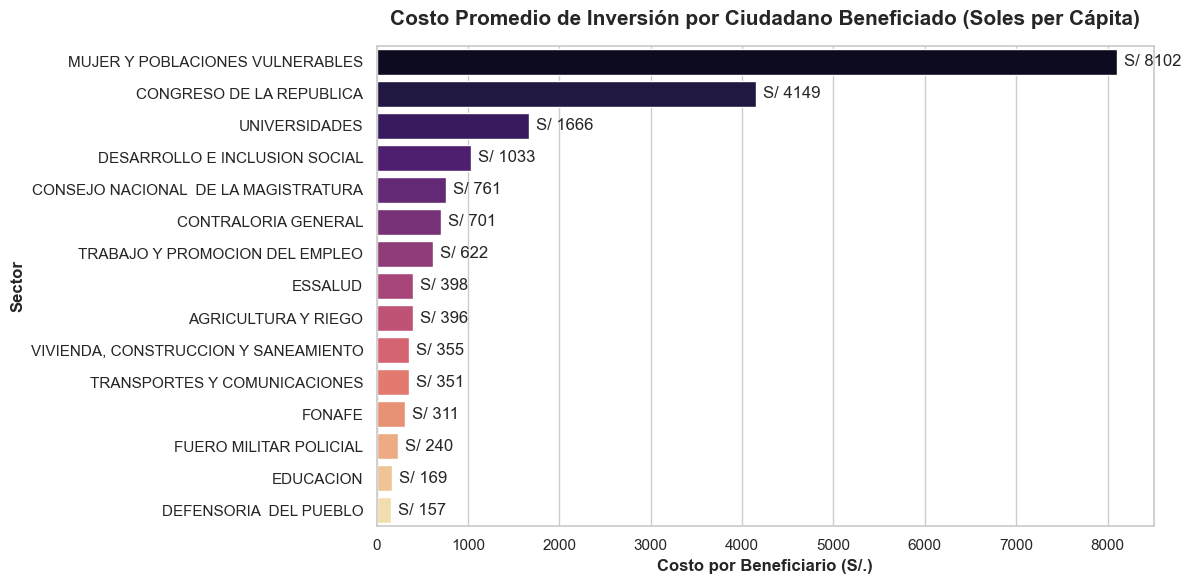

In [7]:
# 1. Extraemos los datos usando la función de rentabilidad social
df_rentabilidad = analizar_rentabilidad_social(engine)

# 2. Filtramos sectores con datos válidos y tomamos el Top 15 más costosos por persona
df_plot = df_rentabilidad[df_rentabilidad['total_beneficiarios'] > 1000].head(15)

# 3. Configuramos la visualización
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

barplot_impacto = sns.barplot(
    data=df_plot, x='costo_por_beneficiario', y='nombre_sector', palette='magma'
)

plt.title('Costo Promedio de Inversión por Ciudadano Beneficiado (Soles per Cápita)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Costo por Beneficiario (S/.)', fontsize=12, fontweight='bold')
plt.ylabel('Sector', fontsize=12, fontweight='bold')

# Agregamos el valor exacto en soles al final de cada barra
for i in barplot_impacto.containers:
    barplot_impacto.bar_label(i, fmt='S/ %d', padding=5)

plt.tight_layout()
plt.show()

* **El sesgo de la infraestructura pesada (Transportes y Saneamiento):** Que el sector Transportes cueste S/ 2,435 por ciudadano impactado no es necesariamente una anomalía corrupta, sino que refleja la naturaleza intensiva en capital del sector (hacer carreteras cuesta miles de millones y beneficia solo a los transeúntes de esa ruta específica). Sin embargo, desde la política pública, evidencia que el Estado asume costos altísimos por individuo para conectar la geografía, un precio ineludible de nuestra compleja topografía.

* **El alto impacto de la infraestructura social (Salud y Educación):** En contraste, sectores vitales para el desarrollo humano como Salud (S/ 483) y Educación (S/ 390) muestran un costo por beneficiario drásticamente menor. Un hospital o un megacolegio, una vez construido, diluye su costo al atender a miles de ciudadanos anualmente durante décadas.

* **La gran paradoja del sistema (El cruce de variables):** Si cruzamos este hallazgo con el gráfico anterior de "Sobrecostos", descubrimos una tragedia de gestión: Educación es uno de los sectores más "baratos" para impactar a un ciudadano, pero es el que peor se planifica (462% de desviación). El Estado gasta fortunas con sobrecostos en el sector que, irónicamente, le daría el mayor retorno social por cada sol invertido.

## 5. Conclusiones

* **1. Crisis de Planificación y Sobrecostos:** Existe una deficiencia estructural en la elaboración de expedientes técnicos, especialmente en sectores críticos como Educación. El hallazgo de un sobrecosto promedio del 462.6% en este sector revela que el Estado no solo gasta mal, sino que es incapaz de prever contingencias, lo que deriva en una "hemorragia" de recursos que podrían destinarse a cerrar otras brechas sociales.

* **2. La Trampa de la Atomización frente a la Concentración:** El análisis del "Efecto Callao" vs. la realidad de Áncash demuestra una gestión territorial esquizofrénica. Mientras algunas regiones fragmentan su presupuesto en miles de micro-obras de bajo impacto (visibilidad política de corto plazo), otras concentran su "riqueza" en un solo megaproyecto, generando una vulnerabilidad financiera extrema donde el desarrollo regional depende del éxito o fracaso de una única obra.

* **3. Inequidad en la Rentabilidad Social:** El indicador de Costo por Beneficiario desmitifica la eficiencia del gasto. Se evidencia que sectores estratégicos para el capital humano (Salud y Educación) tienen una rentabilidad social mucho más alta (menor costo por persona) que los sectores de infraestructura pesada. Sin embargo, la centralización en Lima y Callao (casi el 50% de la inversión) demuestra que el Estado sigue priorizando los nodos logísticos de la capital sobre la integración y el bienestar de las periferias fronterizas y amazónicas.